In [1]:
import pandas as pd 
import numpy as np


In [5]:
import pandas as pd
import os

# Use backslashes for Windows paths
data_path = r"C:\Users\ultra\Desktop\Kaggle Datasets\mercari-price-suggestion-challenge\train.tsv"

# Check if file exists and is readable
if os.path.isfile(data_path):
    try:
        df = pd.read_csv(data_path, sep="\t")
        print(f"File loaded successfully!")
    except PermissionError:
        print(f"Permission denied. Check file permissions at: {data_path}")
else:
    print(f"File not found: {data_path}")
    print("Check if the path exists or adjust the directory name.")

✓ File loaded successfully! Shape: (1482535, 8)
Columns: ['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description']


In [7]:
df

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity
...,...,...,...,...,...,...,...,...
1482530,1482530,Free People Inspired Dress,2,Women/Dresses/Mid-Calf,Free People,20.0,1,"Lace, says size small but fits medium perfectl..."
1482531,1482531,Little mermaid handmade dress,2,Kids/Girls 2T-5T/Dresses,Disney,14.0,0,Little mermaid handmade dress never worn size 2t
1482532,1482532,21 day fix containers and eating plan,2,Sports & Outdoors/Exercise/Fitness accessories,NaN,12.0,0,"Used once or twice, still in great shape."
1482533,1482533,World markets lanterns,3,Home/Home Décor/Home Décor Accents,NaN,45.0,1,There is 2 of each one that you see! So 2 red ...


In [12]:
df.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


In [23]:
df['category_name'].value_counts()

category_name
Women/Athletic Apparel/Pants, Tights, Leggings    60177
Women/Tops & Blouses/T-Shirts                     46380
Beauty/Makeup/Face                                34335
Beauty/Makeup/Lips                                29910
Electronics/Video Games & Consoles/Games          26557
                                                  ...  
Handmade/Dolls and Miniatures/Artist Bears            1
Handmade/Furniture/Fixture                            1
Handmade/Jewelry/Clothing                             1
Vintage & Collectibles/Supplies/Ephemera              1
Handmade/Pets/Blanket                                 1
Name: count, Length: 1287, dtype: int64

In [26]:
df['price'].describe()

count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64

In [32]:
df[df['price'] > 500].count()

train_id             1115
name                 1115
item_condition_id    1115
category_name        1112
brand_name            949
price                1115
shipping             1115
item_description     1115
dtype: int64

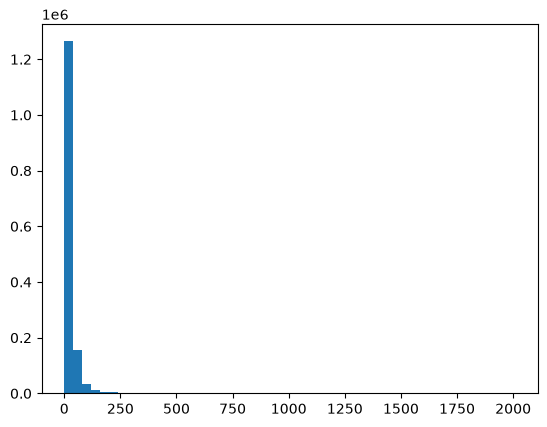

In [38]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=50)
plt.show()

In [42]:
df[df['price']==0].count()

train_id             874
name                 874
item_condition_id    874
category_name        861
brand_name           528
price                874
shipping             874
item_description     874
dtype: int64

In [44]:
## removing the datapoint with zero price

df_clean = df[df['price'] >0]

In [92]:
## applying log transform to data as it is right skewed

df['log_price'] = np.log1p(df['price'])


In [55]:
# First, look at WHAT these items are

df[df['price'] > 500][['name', 'category_name', 'price']].sort_values('price', ascending=False).head(5)

## expensive itemssss 

,name,category_name,price
760469,NEW Chanel WOC Caviar Gold Hardware,Women/Women's Handbags/Shoulder Bag,2009.0
1262245,NEW-Chanel Boy Wallet o Chain WOC Caviar,Women/Women's Handbags/Messenger & Crossbody,2006.0
1393600,David Yurman Wheaton ring,Women/Jewelry/Rings,2004.0
1250053,Brand New Chanel CC Quilted WOC,Women/Women's Handbags/Messenger & Crossbody,2000.0
742113,Chanel Chevron Fuschia Pink 2,Women/Women's Handbags/Shoulder Bag,2000.0


## Dealing With NaNs of Brand_Names 

In [60]:
print(df['brand_name'].isnull().sum())
print(df['brand_name'].isnull().mean()*100,"%")


632682
42.675687251902986 %


In [63]:
df.isnull().sum()
df.isnull().mean()*100

train_id              0.000000
name                  0.000000
item_condition_id     0.000000
category_name         0.426769
brand_name           42.675687
price                 0.000000
shipping              0.000000
item_description      0.000405
dtype: float64

In [64]:
### now let's create more features from the cateogory for our TF-idf

df['cat_main']=df['category_name'].str.split('/').str[0]
df['cat_sub']=df['category_name'].str.split('/').str[1]
df['cat_detail']=df['category_name'].str.split('/').str[2]


In [ ]:
df['name_len']=df['name'].str.len()
df['desc_len']=df['item_description'].str.len()
df['name_len']=df['item_description'].str.split().str.len()

##3 longer description mean more valuablle item(a note for me also ;/)


In [67]:
## now increase the input singnals 

df['has_brand'] = df['brand_name'].notnull().astype(int)
df['brand_name'] = df['brand_name'].fillna("unknown")


In [ ]:
## validation of above logic 

df.groupby('has_brand')['price'].median()

has_brand
0    14.0
1    20.0
Name: price, dtype: float64

In [70]:
df.groupby('cat_main')['price'].median().sort_values(ascending = False)

cat_main
Men                       21.0
Women                     19.0
Home                      18.0
Sports & Outdoors         16.0
Vintage & Collectibles    16.0
Beauty                    15.0
Electronics               15.0
Kids                      14.0
Other                     14.0
Handmade                  12.0
Name: price, dtype: float64

In [74]:
df.groupby('cat_sub')['price'].median().sort_values(ascending = False).tail(15)

cat_sub
Paper Ephemera               11.0
Cell Phones & Accessories    11.0
Books                        11.0
Accessories                  10.0
Artwork                      10.0
Art                          10.0
Books and Zines              10.0
Media                        10.0
Geekery                      10.0
Needlecraft                  10.0
Children                      9.0
Magazines                     9.0
Quilts                        8.0
Trading Cards                 8.0
Paper Goods                   6.0
Name: price, dtype: float64

In [75]:
df.groupby('cat_detail')['price'].median().sort_values(ascending = False).head(15)

cat_detail
Standard                       145.0
Air Conditioners               131.0
Lightweight                    105.0
Laptops & Netbooks             100.0
Women's Golf Clubs             100.0
Travel Systems                  95.0
Satchel                         90.0
Desktops & All-In-Ones          89.5
Oils & Fluids                   85.0
Lenses & Filters                70.0
Track & Sweat Suits             66.0
Cell Phones & Smartphones       65.0
Wind & Woodwind Instruments     64.0
Digital Cameras                 61.0
Feather Beds                    60.0
Name: price, dtype: float64

In [ ]:

## checking cardinaltiy

print(df['cat_main'].nunique())  ### 10 OHE
print(df['cat_sub'].nunique())  ### Target Encoding replacing with mean
print(df['cat_detail'].nunique()) ### Target Encoding replacing mean

10
113
870


In [ ]:
### what is this standard

df[df['cat_detail']=='Standard'][['name','price','cat_main']].head(10)

,name,price,cat_main
11730,Minnie Mouse Stroller,50.0,Kids
73876,Baby Jogger City Premiere,275.0,Kids
144452,Mamas and Papas Sola,150.0,Kids
380115,Bugaboo bee limited edition pendleton,76.0,Kids
383116,2015 uppababy vista,480.0,Kids
427316,Mama and papa Urbo 2 stroller,230.0,Kids
446858,Orbit Baby G3 Black Stroller Seat-NEW,145.0,Kids
452110,UppaBaby Jake Bassinet New Model,70.0,Kids
769140,G2 Orbit Baby Stroller Seat,65.0,Kids
894690,HOLD for LESLIE Nuna IVVI Stroller,315.0,Kids


In [81]:
## target map

cat_sub_map = df.groupby('cat_sub')['price'].mean()
cat_detail_map = df.groupby('cat_detail')['price'].mean()

df['cat_sub_encoded'] = df['cat_sub'].map(cat_sub_map)
df['cat_detail_encoded'] = df['cat_detail'].map(cat_detail_map)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,cat_main,cat_sub,cat_detail,name_len,desc_len,has_brand,log_price
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,unknown,10.0,1,No description yet,Men,Tops,T-shirts,3.0,18.0,0,2.397895
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...,Electronics,Computers & Tablets,Components & Parts,36.0,188.0,1,3.970292
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...,Women,Tops & Blouses,Blouse,29.0,124.0,1,2.397895
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,unknown,35.0,1,New with tags. Leather horses. Retail for [rm]...,Home,Home Décor,Home Décor Accents,32.0,173.0,0,3.583519
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,unknown,44.0,0,Complete with certificate of authenticity,Women,Jewelry,Necklaces,5.0,41.0,0,3.806662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482530,1482530,Free People Inspired Dress,2,Women/Dresses/Mid-Calf,Free People,20.0,1,"Lace, says size small but fits medium perfectl...",Women,Dresses,Mid-Calf,22.0,128.0,1,3.044522
1482531,1482531,Little mermaid handmade dress,2,Kids/Girls 2T-5T/Dresses,Disney,14.0,0,Little mermaid handmade dress never worn size 2t,Kids,Girls 2T-5T,Dresses,8.0,48.0,1,2.708050
1482532,1482532,21 day fix containers and eating plan,2,Sports & Outdoors/Exercise/Fitness accessories,unknown,12.0,0,"Used once or twice, still in great shape.",Sports & Outdoors,Exercise,Fitness accessories,8.0,41.0,0,2.564949
1482533,1482533,World markets lanterns,3,Home/Home Décor/Home Décor Accents,unknown,45.0,1,There is 2 of each one that you see! So 2 red ...,Home,Home Décor,Home Décor Accents,28.0,120.0,0,3.828641


In [94]:
df.drop(columns=['cat_sub_encoded', 'cat_detail_encoded'], inplace=True)

KeyError: "['cat_sub_encoded', 'cat_detail_encoded'] not found in axis"

In [112]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)


X_test

In [113]:
cat_sub_map = df.groupby('cat_sub')['price'].mean()

cat_detail_map = df.groupby('cat_detail')['price'].mean()

In [114]:

X_train['cat_sub_encoded']    = X_train['cat_sub'].map(cat_sub_map)
X_test['cat_sub_encoded']     = X_test['cat_sub'].map(cat_sub_map)

X_train['cat_detail_encoded'] = X_train['cat_detail'].map(cat_detail_map)
X_test['cat_detail_encoded']  = X_test['cat_detail'].map(cat_detail_map)

In [ ]:

## fliing test data with global mean
global_mean = y_train.mean
X_test['cat_sub_encoded'] = X_test['cat_sub_encoded'].fillna(global_mean)
X_test['cat_detail_encoded'] = X_test['cat_detail_encoded'].fillna(global_mean)

In [119]:
# Check if cat_main columns exist
print([col for col in X_train.columns if 'cat_main' in col])

# Also check all columns
print(X_train.columns.tolist())

['cat_main']
['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description', 'cat_main', 'cat_sub', 'cat_detail', 'name_len', 'desc_len', 'has_brand', 'cat_sub_encoded', 'cat_detail_encoded']


In [120]:
X_train

,train_id,name,item_condition_id,category_name,brand_name,shipping,item_description,cat_main,cat_sub,cat_detail,name_len,desc_len,has_brand,cat_sub_encoded,cat_detail_encoded
1416089,1416089,LuLaRoe kids L/XL leggings,3,Kids/Boys (4+)/Bottoms,unknown,1,Worn once. Still in great condition,Kids,Boys (4+),Bottoms,6.0,35.0,0,27.849325,16.833355
1423955,1423955,Bundle 5 Display mannequins,1,Other/Other/Other,unknown,0,Brand new,Other,Other,Other,2.0,9.0,0,24.865364,23.694827
403867,403867,LIVING PROOF PERFECT HAIR DAY DRY SHAMPO,1,Beauty/Hair Care/Styling Products,unknown,0,This listing is for 3 full size bottles of liv...,Beauty,Hair Care,Styling Products,86.0,463.0,0,19.374646,16.191356
701974,701974,Palazzo pants,2,Women/Pants/Casual Pants,unknown,0,Like new adorable black and white palazzo pant...,Women,Pants,Casual Pants,111.0,589.0,0,19.645373,18.400573
1124330,1124330,RESERVED FOR Ms Jas PINK BOYSHORTS LARGE,1,Women/Underwear/Panties,PINK,1,NEW WITH TAGS MORNING SKY SHEER SEAFOAM OLIVE ...,Women,Underwear,Panties,9.0,51.0,1,18.097813,17.200451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,259178,Brooks brothers girls,3,Kids/Girls (4+)/Dresses,Brooks Brothers,0,"Beautiful dress, another of her favorites. Sz....",Kids,Girls (4+),Dresses,11.0,73.0,1,18.552418,18.824669
1414414,1414414,LulaRoe Randy size Large,1,Women/Tops & Blouses/Knit Top,unknown,0,"Brand new, never worn or washed, size Large, N...",Women,Tops & Blouses,Knit Top,13.0,83.0,0,18.237514,19.711157
131932,131932,This sale is,1,Kids/Toys/Dolls & Accessories,unknown,0,American girl doll Tenney. Comes with the doll...,Kids,Toys,Dolls & Accessories,18.0,97.0,0,21.522112,26.984882
671155,671155,Iphone headphone lightning cable split,1,Electronics/Cell Phones & Accessories/Cables &...,Apple,0,No description yet,Electronics,Cell Phones & Accessories,Cables & Adapters,3.0,18.0,1,30.142278,10.941572


## MOdel Training

In [121]:
X_train = pd.get_dummies(X_train,columns=['cat_main'],drop_first=True)
X_test = pd.get_dummies(X_test,columns=['cat_main'],drop_first=True)

# Align columns between train and test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## Adding more features

In [138]:
X_train['name_len']       = X_train['name'].str.len()
X_train['desc_len']       = X_train['item_description'].str.len()
X_train['name_word_count']= X_train['name'].str.split().str.len()
X_train['desc_word_count']= X_train['item_description'].str.split().str.len()

X_test['name_len']        = X_test['name'].str.len()
X_test['desc_len']        = X_test['item_description'].str.len()
X_test['name_word_count'] = X_test['name'].str.split().str.len()
X_test['desc_word_count'] = X_test['item_description'].str.split().str.len()

In [122]:
cat_main_cols = [col for col in X_train.columns if col.startswith('cat_main_')]
print(cat_main_cols)
# Should show 9 columns (10 categories - 1 for drop_first)

['cat_main_Electronics', 'cat_main_Handmade', 'cat_main_Home', 'cat_main_Kids', 'cat_main_Men', 'cat_main_Other', 'cat_main_Sports & Outdoors', 'cat_main_Vintage & Collectibles', 'cat_main_Women']


In [128]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

In [139]:
features = [
    'item_condition_id',
    'shipping',
    'has_brand',
    'cat_sub_encoded',
    'cat_detail_encoded'
]
features += ['name_len','desc_len','name_word_count',"desc_word_count"]
cat_main_cols = [col for col in X_train.columns if col.startswith('cat_main_')]
features += cat_main_cols

In [140]:
model = lgb.LGBMRegressor(n_estimators=500, random_state=42)
model.fit(X_train[features], y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 1186028, number of used features: 18
[LightGBM] [Info] Start training from score 2.978479


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [141]:

y_pred = model.predict(X_test[features])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (log scale): {rmse:.4f}")
print(f"RMSE (actual $): {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))):.2f}")

RMSE (log scale): 0.5980
RMSE (actual $): 35.50
